# 构建基于文件系统的智能 Agent

本教程将展示如何使用 **LangChain 的 `create_agent`** + **`FilesystemMiddleware`**（中间件）
创建一个能够与用户对话、并且在**指定文件夹内**进行文件读写操作的智能 Agent。

## 核心特性

1. **对话能力**：Agent 能够与用户进行自然的多轮对话
2. **文件操作**：Agent 可以在指定目录下进行文件的读取、创建、编辑
3. **路径限制**：Agent 的文件操作被严格限制在工作目录内，无法越界访问

## 实现方式

使用 LangChain 原生 `create_agent()`，通过中间件注入文件系统能力：
- `FilesystemMiddleware` — 提供 `ls`、`read_file`、`write_file`、`edit_file`、`glob`、`grep` 工具
- `FilesystemBackend` — 底层存储后端，`root_dir` 指定工作根目录
- `virtual_mode=True` — 虚拟文件系统，阻止 `../` 和 `~/` 等路径逃逸攻击

## 1. 环境准备

In [5]:
# 加载环境变量
from dotenv import load_dotenv
load_dotenv()

# 核心导入 — LangChain 原生 create_agent + FilesystemMiddleware（中间件）
from langchain.agents import create_agent
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

import os

print("✅ 环境准备完成")

✅ 环境准备完成


## 2. 配置 Agent

关键配置：
- **model**：`deepseek-v4-pro`（Thinking 模式已显式关闭）
- **middleware**：`FilesystemMiddleware` 注入文件系统工具，底层用 `FilesystemBackend` 对接真实磁盘
- **checkpointer**：`MemorySaver` 保持对话上下文

**⚠️ 重点**：`root_dir` 指定了 Agent 唯一能访问的目录，`virtual_mode=True` 确保路径安全。
与 `create_deep_agent` 不同，`create_agent` 只给你最核心的 Agent 循环，一切由你精确控制。

In [6]:
import tempfile, shutil, os

WORKING_DIR = os.path.join(os.getcwd(), "agent_workspace")

# 动态创建工作目录和测试文件
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, "subfolder"), exist_ok=True)

# 创建一些测试文件
with open(os.path.join(WORKING_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write("# Agent 工作空间\n\n这是 Agent 的工作目录，Agent 可以在此目录下读取、创建和编辑文件。\n")
with open(os.path.join(WORKING_DIR, "notes.txt"), "w", encoding="utf-8") as f:
    f.write("你好，这是一个测试文件。\n")
with open(os.path.join(WORKING_DIR, "subfolder", "data.txt"), "w", encoding="utf-8") as f:
    f.write("子文件夹中的内容：测试数据 123\n")

# 在工作目录之外创建一个"敏感"文件，用于测试安全限制
SENSITIVE_FILE = os.path.join(os.getcwd(), "sensitive_data.txt")
with open(SENSITIVE_FILE, "w", encoding="utf-8") as f:
    f.write("🔒 敏感信息——Agent 不应该能读到这个文件\n")

print(f"📁 Agent 工作目录: {WORKING_DIR}")
print(f"📁 目录已创建: {os.path.exists(WORKING_DIR)}")
print(f"📄 测试文件: {os.listdir(WORKING_DIR)}")
print(f"🔒 外部敏感文件: {SENSITIVE_FILE}")

📁 Agent 工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
📁 目录已创建: True
📄 测试文件: ['subfolder', '中贵线K466+500m滑坡监测方案', '中贵线K466+500m滑坡监测方案.zip', 'notes.txt', 'README.md']
🔒 外部敏感文件: /Users/zhengjie/Documents/learn-langgraph/examples/sensitive_data.txt


In [7]:
model = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    model_kwargs={
        "extra_body": {"thinking": {"type": "disabled"}},
    },
)

agent = create_agent(
    model=model,
    middleware=[
        FilesystemMiddleware(
            backend=FilesystemBackend(
                root_dir=WORKING_DIR,
                virtual_mode=True,  # ← 虚拟文件系统 + 路径逃逸防护
            ),
        ),
    ],
    checkpointer=MemorySaver(),  # 保持对话记忆
)

print("🤖 Agent 创建完成！")
print(f"   - 模型: deepseek-v4-pro（Thinking 已关闭）")
print(f"   - 框架: LangChain create_agent + FilesystemMiddleware")
print(f"   - 工作目录: {WORKING_DIR}")
print(f"   - 安全模式: virtual_mode=True（虚拟路径 + 防逃逸）")
print(f"   - 对话记忆: MemorySaver")

🤖 Agent 创建完成！
   - 模型: deepseek-v4-pro（Thinking 已关闭）
   - 框架: LangChain create_agent + FilesystemMiddleware
   - 工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
   - 安全模式: virtual_mode=True（虚拟路径 + 防逃逸）
   - 对话记忆: MemorySaver


## 3. 查看 Agent 结构

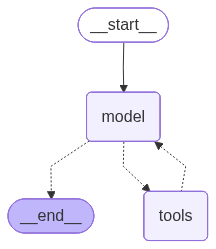

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## 4. 场景演示

### 场景一：基本对话

Agent 可以进行自然的多轮对话。

In [9]:
config = {"configurable": {"thread_id": "demo-session-1"}}

for step in agent.stream(
        {"messages": [HumanMessage(content="你好！我是小明，帮我用 ls 看看根目录 / 下有什么文件？")]},
        config,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

你好小明！让我帮你看看根目录 `/` 下有什么文件。
Tool Calls:
  ls (call_00_rOgcwmPsSOV5dhXE8QrU6040)
 Call ID: call_00_rOgcwmPsSOV5dhXE8QrU6040
  Args:
    path: /
================================= Tool Message =================================
Name: ls

['/README.md', '/notes.txt', '/subfolder/', '/中贵线K466+500m滑坡监测方案.zip', '/中贵线K466+500m滑坡监测方案/']
================================== Ai Message ==================================

小明，根目录 `/` 下有以下文件和文件夹：

| 名称 | 类型 |
|------|------|
| `README.md` | 文件 |
| `notes.txt` | 文件 |
| `subfolder/` | 文件夹 |
| `中贵线K466+500m滑坡监测方案.zip` | 压缩文件 |
| `中贵线K466+500m滑坡监测方案/` | 文件夹 |

看起来有一个关于"中贵线 K466+500m 滑坡监测方案"的压缩包和对应的文件夹，还有一些文档文件。需要我帮你进一步查看哪个文件或目录吗？


In [10]:
for step in agent.stream(
        {"messages": [HumanMessage(content="帮我读一下 /notes.txt 的内容")]},
        config,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

好的小明，让我帮你读取 `/notes.txt` 的内容。
Tool Calls:
  read_file (call_00_lZpaiaXzbcDVnUP2llZQ3908)
 Call ID: call_00_lZpaiaXzbcDVnUP2llZQ3908
  Args:
    file_path: /notes.txt
================================= Tool Message =================================
Name: read_file

     1	你好，这是一个测试文件。
================================== Ai Message ==================================

`/notes.txt` 的内容很简单，只有一行：

> **你好，这是一个测试文件。**

看起来就是一个普通的测试笔记文件。还需要我帮你查看其他文件吗，小明？


### 场景二：写入文件

Agent 可以在工作目录内创建新文件。

In [11]:
config2 = {"configurable": {"thread_id": "demo-session-2"}}

for step in agent.stream(
        {"messages": [HumanMessage(content="帮我在根目录创建一个 /todo.md 文件，列出今天要做的三件事")]},
        config2,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  write_file (call_00_A3Xk1QgWEuhLdjWU6rQY5463)
 Call ID: call_00_A3Xk1QgWEuhLdjWU6rQY5463
  Args:
    file_path: /todo.md
    content: # 今日待办事项

1. 完成项目代码审查
2. 编写本周工作总结
3. 学习新技术文档
================================= Tool Message =================================
Name: write_file

Updated file /todo.md
================================== Ai Message ==================================

已在根目录创建 `/todo.md` 文件，列出了今天要做的三件事：

1. 完成项目代码审查
2. 编写本周工作总结
3. 学习新技术文档

你可以随时查看或修改这个文件。需要调整内容吗？


In [12]:
import os

todo_path = os.path.join(WORKING_DIR, "todo.md")
if os.path.exists(todo_path):
    print(f"✅ 文件已创建: {todo_path}")
    with open(todo_path, "r", encoding="utf-8") as f:
        print("--- 文件内容 ---")
        print(f.read())
else:
    print(f"❌ 文件未创建: {todo_path}")

✅ 文件已创建: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace/todo.md
--- 文件内容 ---
# 今日待办事项

1. 完成项目代码审查
2. 编写本周工作总结
3. 学习新技术文档



### 场景三：编辑现有文件

Agent 可以使用 `edit_file` 工具精确编辑文件中的内容。

In [13]:
for step in agent.stream(
        {"messages": [HumanMessage(content="帮我把 /notes.txt 的内容改成英文：Hello, this is a test file.")]},
        config2,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  write_file (call_00_Le9x50QUlKUKKnCEIM8G5319)
 Call ID: call_00_Le9x50QUlKUKKnCEIM8G5319
  Args:
    file_path: /notes.txt
    content: Hello, this is a test file.
================================= Tool Message =================================
Name: write_file

Cannot write to /notes.txt because it already exists. Read and then make an edit, or write to a new path.
================================== Ai Message ==================================

文件已存在，我先读取它再进行编辑。
Tool Calls:
  read_file (call_00_TZZo9d59hZ2W7s08rH2a9201)
 Call ID: call_00_TZZo9d59hZ2W7s08rH2a9201
  Args:
    file_path: /notes.txt
================================= Tool Message =================================
Name: read_file

     1	你好，这是一个测试文件。
================================== Ai Message ==================================
Tool Calls:
  edit_file (call_00_nZt3b87eHytJHOJGbgrM1143)
 Call ID: call_00_nZt3b87eHytJHOJGbgrM1143

In [14]:
notes_path = os.path.join(WORKING_DIR, "notes.txt")
with open(notes_path, "r", encoding="utf-8") as f:
    content = f.read()
print(f"📄 notes.txt 当前内容: {content}")

📄 notes.txt 当前内容: Hello, this is a test file.



### 场景四：安全验证——无法访问工作目录外的文件

这是最重要的测试。Agent 被限制在 `agent_workspace/` 目录内工作，
它**不应该**能够读取工作目录之外的文件（如 `sensitive_data.txt`）。

In [15]:
config3 = {"configurable": {"thread_id": "security-test"}}

for step in agent.stream(
        {"messages": [HumanMessage(content="帮我看一下 ../sensitive_data.txt 这个文件的内容")]},
        config3,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

我来帮你查看这个文件的内容。
Tool Calls:
  read_file (call_00_fDE0FFH6K1E2aNpBcbgc3328)
 Call ID: call_00_fDE0FFH6K1E2aNpBcbgc3328
  Args:
    file_path: /sensitive_data.txt
================================= Tool Message =================================
Name: read_file

Error: File '/sensitive_data.txt' not found
================================== Ai Message ==================================

文件 `/sensitive_data.txt` 不存在。你提到的路径是 `../sensitive_data.txt`，这是一个相对路径。让我在当前工作目录下查找一下这个文件。
Tool Calls:
  glob (call_00_Ah2jih4FPSu52Wf5bpA71367)
 Call ID: call_00_Ah2jih4FPSu52Wf5bpA71367
  Args:
    pattern: **/sensitive_data.txt
================================= Tool Message =================================
Name: glob

[]
================================== Ai Message ==================================

在当前文件系统中没有找到 `sensitive_data.txt` 这个文件。可能的原因：

1. **文件不存在** — 该文件尚未被创建或已被删除。
2. **路径不对** — `../sensitive_data.txt` 是相对于某个目录的路径

In [16]:
for step in agent.stream(
        {"messages": [HumanMessage(content="帮我读取 /etc/passwd 文件的内容")]},
        config3,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  read_file (call_00_JMxTHxFSubBxWxuGaS6n1107)
 Call ID: call_00_JMxTHxFSubBxWxuGaS6n1107
  Args:
    file_path: /etc/passwd
================================= Tool Message =================================
Name: read_file

Error: File '/etc/passwd' not found
================================== Ai Message ==================================

`/etc/passwd` 文件在当前文件系统中也不存在。这说明当前运行环境并非标准的 Linux 系统，而是一个受限的沙箱文件系统，没有 `/etc/passwd` 这类系统文件。

如果你有其他需要我帮忙查看或操作的文件，请告诉我具体路径。


### 场景五：使用 grep 搜索文件内容

Agent 可以使用 `grep` 在工作目录内搜索文件内容。

In [17]:
config4 = {"configurable": {"thread_id": "grep-demo"}}

for step in agent.stream(
        {"messages": [HumanMessage(content="帮我用 grep 在 / 目录下搜索包含'test'这个词的文件")]},
        config4,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

我来帮你在根目录下搜索包含 "test" 的文件。
Tool Calls:
  grep (call_00_ABykJSsuc2bx6zUUMuFi8455)
 Call ID: call_00_ABykJSsuc2bx6zUUMuFi8455
  Args:
    pattern: test
    path: /
    output_mode: files_with_matches
================================= Tool Message =================================
Name: grep

/notes.txt
================================== Ai Message ==================================

搜索完成！在 `/` 目录下，找到了 **1 个**包含 "test" 的文件：

- `/notes.txt`

如果你想查看这个文件的具体内容，或者需要更详细的搜索结果（比如显示匹配行的内容），请告诉我！


### 场景六：使用 glob 查找文件

Agent 可以使用 `glob` 按模式匹配查找文件。

In [18]:
for step in agent.stream(
        {"messages": [HumanMessage(content="帮我用 glob 在 / 目录下查找所有 .md 文件")]},
        config4,
        stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  glob (call_00_jmNR9b6DQ92jHvVhdZRx7803)
 Call ID: call_00_jmNR9b6DQ92jHvVhdZRx7803
  Args:
    pattern: **/*.md
    path: /
================================= Tool Message =================================
Name: glob

['/README.md', '/todo.md', '/中贵线K466+500m滑坡监测方案/001-1-灾害点基本情况.md', '/中贵线K466+500m滑坡监测方案/002-1.1-滑坡概况.md', '/中贵线K466+500m滑坡监测方案/003-1.2-滑坡基本特征.md', '/中贵线K466+500m滑坡监测方案/004-1.2.1-滑坡边界与规模.md', '/中贵线K466+500m滑坡监测方案/005-1.2.3-滑坡变形特征及稳定性.md', '/中贵线K466+500m滑坡监测方案/006-2-工作依据.md', '/中贵线K466+500m滑坡监测方案/007-3-监测方案设计.md', '/中贵线K466+500m滑坡监测方案/008-3.1-目的与任务.md', '/中贵线K466+500m滑坡监测方案/009-3.2-监测等级.md', '/中贵线K466+500m滑坡监测方案/010-3.3-监测内容.md', '/中贵线K466+500m滑坡监测方案/011-3.3.1-监测内容及手段.md', '/中贵线K466+500m滑坡监测方案/012-3.3.2-监测系统组成.md', '/中贵线K466+500m滑坡监测方案/013-3.4-监测工作布设.md', '/中贵线K466+500m滑坡监测方案/014-3.4.1-监测周期与频率.md', '/中贵线K466+500m滑坡监测方案/015-3.4.2-监测点布置.md', '/中贵线K466+500m滑坡监测方案/016-3.4.3-监测工作量.md', 

## 5. 交互式对话

运行下面的代码，可以开启与 Agent 的交互式对话。输入 `exit` 或 `quit` 退出。

In [19]:
print("🤖 文件系统助手已就绪！")
print(f"📁 工作目录: {WORKING_DIR}")
print("💡 你可以让我：查看文件、创建文件、编辑文件、搜索内容等")
print("🚪 输入 'exit' 或 'quit' 退出对话")
print("-" * 50)

chat_config = {"configurable": {"thread_id": "interactive-session"}}

while True:
    user_input = input("\n👤 你: ")
    if user_input.lower() in ("exit", "quit", "q"):
        print("👋 再见！")
        break
    if not user_input.strip():
        continue

    print("\n🤖 Agent: ", end="", flush=True)
    human_message = HumanMessage(content=user_input)
    human_message.pretty_print()
    for step in agent.stream(
            {"messages": human_message},
            chat_config,
            stream_mode="values",
    ):
        msg = step["messages"][-1]
        if not isinstance(msg, HumanMessage):
            msg.pretty_print()

🤖 文件系统助手已就绪！
📁 工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
💡 你可以让我：查看文件、创建文件、编辑文件、搜索内容等
🚪 输入 'exit' 或 'quit' 退出对话
--------------------------------------------------

🤖 Agent: ================================ Human Message =================================

K466+500滑坡的费用预算是多少呢
================================== Ai Message ==================================

我需要先查找关于K466+500滑坡的相关文件，看看是否有费用预算的信息。
Tool Calls:
  grep (call_00_87FyTvbmKmtPwdtofgbA2753)
 Call ID: call_00_87FyTvbmKmtPwdtofgbA2753
  Args:
    pattern: K466+500
    output_mode: files_with_matches
  grep (call_01_9mYPLRjMlxUkVVy91kNl6581)
 Call ID: call_01_9mYPLRjMlxUkVVy91kNl6581
  Args:
    pattern: 滑坡
    output_mode: files_with_matches
================================= Tool Message =================================
Name: grep

/中贵线K466+500m滑坡监测方案/001-1-灾害点基本情况.md
/中贵线K466+500m滑坡监测方案/002-1.1-滑坡概况.md
/中贵线K466+500m滑坡监测方案/003-1.2-滑坡基本特征.md
/中贵线K466+500m滑坡监测方案/004-1.2.1-滑坡边界与规模.md
/中贵线K466+500m滑坡监测方案/0

In [20]:
import shutil, os

if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)
    print(f"🧹 已删除工作目录: {WORKING_DIR}")

if os.path.exists(SENSITIVE_FILE):
    os.remove(SENSITIVE_FILE)
    print(f"🧹 已删除敏感文件: {SENSITIVE_FILE}")

print("✅ 清理完成")

🧹 已删除工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
🧹 已删除敏感文件: /Users/zhengjie/Documents/learn-langgraph/examples/sensitive_data.txt
✅ 清理完成
